# Dataset Augmentation
The idea of dataset augmentation is: modify the trainings data without changing the content. For a dataset of animal pictures, a simple example of dataset augmentation is to mirror the images on the vertical axis. This modifies the samples/pixels of the image without changing the content.
These modifications of the trainings data enlarges the amount of available trainings data, because the above mentioned flip on the vertical axis doubles the amount of animal pictures for each class (the original image and the flipped image can be used for training). By enlarging the number of training samples, the trained classificator becomes more robust against valid modifications of images.  

## Vocoder
Vocoder is an artificial word combined out of voice and encoder.
Vocoder is a general word for all algorithms designed to analyse and synthesize speech.
For example, they can be used to change the pitch (the basic frequency) of sounds or they can align the time axis for different acoustical signals by time stretching.

The vocoder is the ideal software to analyse the properties of speech (pitch, speed, envelope, ...) and to play with these properties in order to get better insights in the topic of digital speech processing. Additionally, it can be checked, which parameters of a vocoder leads to a high quality of speech signals and which parameters leads to an acceptable speech intelligibility. For Speech recognition software, an acceptable speech intelligibility should be sufficient as feature input for a neural network.

In the context of this lesson, the phase vocoder is used. Other vocoder types are ignored.
The phase vocoder analyses the spectrogram of the signal.
This spectrogram is modified, by e.g. a timestretch or a pitch shift.
Then the phase of the modified spectrogram is estimated. In this example, the RTISI algorithm is used for phase estimation.
Finally, the inverse short time Fourier transform evaluates the output wave file.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(1, '../Basics')
import WaveFileHandling

## RTISI
The vocoder changes/modifies in general the magnitudes of a spectrogram. Therefore, the original phase of the complex valued spectrogram are not longer valid or are no longer matching the neighbouring spectra over the temporal axis.
The RTISI algorithm, introduced in Real-Time Signal Estimation From Modified Short-Time Fourier Transform Magnitude Spectra estimates valid phases/angles for the modified spectrogram.

In [2]:
class CRTISI(object):
    
    def __init__(self, hs, AnalysisWindow, SynthesisWindow = None):
        self.__hs = hs
        self.__AnalysisWindow = AnalysisWindow
        if SynthesisWindow is None:
            self.__SynthesisWindow = AnalysisWindow
        else:
            self.__SynthesisWindow = SynthesisWindow
        self.__Buffer = None
        self.__WindowSum = None
        self.__MaxIter = 5
            
    def __UpdateBuffer(self, ColumnOfSpectrogram):
        if self.__Buffer is None:
            Lookahead = int(self.__AnalysisWindow.shape[0] / self.__hs - 1)
            self.__Buffer = np.zeros((ColumnOfSpectrogram.shape[0], 2*Lookahead+1), dtype=complex)
            self.__FFTLen = 2 * (self.__Buffer.shape[0] - 1)
        else:
            NumberOfColumns = self.__Buffer.shape[1]
            self.__Buffer[:, 0:NumberOfColumns-1] = np.copy(self.__Buffer[:, 1:NumberOfColumns])
        self.__Buffer[:, -1] = np.copy(ColumnOfSpectrogram)            
    
    def GetLatencyInSamples(self):
        return (self.__Buffer.shape[1] // 2) * self.__hs
    
    def __GetWindowSize(self):
        return self.__AnalysisWindow.shape[0]
    
    def __GetWindowSum(self):
        if self.__WindowSum is None:
            ws = self.__GetWindowSize()
            self.__WindowSum = np.zeros((self.__hs * (self.__Buffer.shape[1] - 1) + ws))
            for column in range(self.__Buffer.shape[1]):
                idx1 = column * self.__hs
                idx2 = idx1 + ws
                self.__WindowSum[idx1:idx2] += self.__AnalysisWindow * self.__SynthesisWindow
        return self.__WindowSum
    
    def __OverlapAdd(self):
        # transform back into time-domain
        x = np.fft.irfft(self.__Buffer, axis = 0)
        # overlap add
        ws = self.__GetWindowSize()
        y = np.zeros((self.__hs * (x.shape[1] - 1) + ws))
        for column in range(x.shape[1]):
            idx1 = column*self.__hs
            idx2 = idx1 + ws
            LocalBlock = x[0:ws, column] * self.__SynthesisWindow
            y[idx1:idx2] += LocalBlock
            if column == x.shape[1] // 2:
                result = LocalBlock
        y /= self.__GetWindowSum()
        return y, result
    
    def __UpdatePhases(self, y):
        for column in range(self.__Buffer.shape[1] // 2, self.__Buffer.shape[1]):
            idx1 = column*self.__hs
            idx2 = idx1 + self.__GetWindowSize()
            X = np.fft.rfft(y[idx1:idx2] * self.__AnalysisWindow, n = self.__FFTLen)
            #if column == self.__Buffer.shape[1] // 2:
            #    SNR = 10*np.log10(np.sum(np.abs(self.__Buffer)**2)/np.sum((np.abs(X) - np.abs(self.__Buffer[:, column]))**2))
            self.__Buffer[:, column] = np.abs(self.__Buffer[:, column]) * X / np.abs(X)
        #return SNR
    
    def ProcessNewColumnOfSpectrogram(self, ColumnOfSpectrogram):
        self.__UpdateBuffer(ColumnOfSpectrogram)
        y, result = self.__OverlapAdd()
        for iter in range(self.__MaxIter):
            self.__UpdatePhases(y)
            y, result = self.__OverlapAdd()
            # After evaluating the final result in the final iteration, no __UpdatePhases can be called, because from now on,
            # the result is fixed and given back to the user. Therefore, the corresponding phase of the corresponding column
            # in the self.__Buffer is no longer changeable.
            # Therefore the iteration order is:
            # first update phases second evaluate overlap add
        return result

## Initial Bandpass

The simplest way of denoising a sensor signal is a [bandpass](../Week05_Denoising_Bandpass/01_DiscreteFiltering.ipynb). If the frequency range of the wanted signal is known, all other frequencies can be suppressed. By this simple algorithm, the SNR is increased.

For human voice,the relevant frequency range is assumed in the range:

$50 \text{ Hz}< f < 7000 \text{ Hz}$.

The initial bandpass is configured by the parameters CutoffFrequencyBandpassLowInHertz and CutoffFrequencyBandpassHighInHertz.

## Changing the speed
The vocoder can be used to change the speed of the playback. For this, the synthesis windows must use a different hop size than the analysis windows. The speed can be changed by the parameter TimeStretchFactor.
A TimeStretchFactor greater than $1$ slows the voice down, a TimeStretchFactor smaller than $1$ speeds the voice up.

## Changing the pitch
The class CTransformPitchshift evaluates a linear interpolation between two neighbouring frequency bins of the DFT.
This linear interpolation can be expressed by a matrix multiplication with the transform matrix self.__T.

The transform Matrix self.__T is evaluated each time, the parameter ShiftByFactor changes. This evaluation is done in the private procedure __EvaluateTransformMatrix.
The linear interpolation is implemented as follows: The magnitude spectrogram of the $k$-th frequency bin corresponds to the Targetfrequency $\Delta_f\cdot k$ in Hertz. The magnitude of this Targetfrequency should be the same, as the magnitude of the old spectrum $X$ at the Sourcefrequency, which is Targetfrequency changed by the shift factor.
Due to the discrete frequency resolution of the DFT, only discrete frequency bins are defined, namely $n\cdot\Delta_f$. Therefore, the new magnitude at frequency TargetFrequency cannot be directly taken from the source bin $n$. Instead, a linear interpolation of two neighbouring bins is done.

The public procedure TransformPitchshift checks, if the current ShiftByFactor is valid. If not, the transform matrix is updated. Finally, the transform matrix is applied by the call np.matmul(self.__T, X).

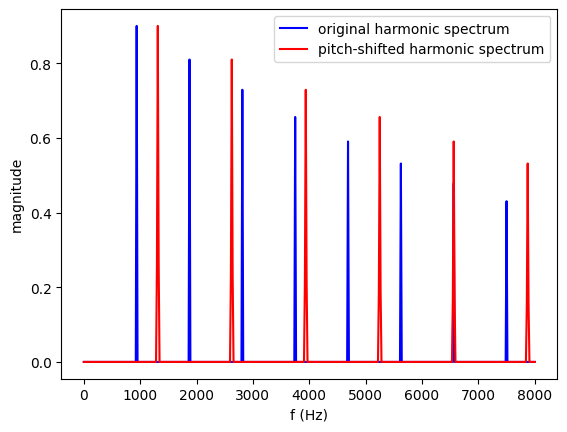

In [3]:
class CTransformPitchshift(object):
    
    def __init__(self):
        self.__ShiftByFactor = -1.0
        self.__XShape0 = 0
        
    def __EvaluateTransformMatrix(self, SamplingRate):
        FFTLen = 2*(self.__XShape0-1)
        Delta_f = SamplingRate / FFTLen
        self.__T = np.zeros((self.__XShape0, self.__XShape0))
        for k in range(self.__XShape0):
            TargetFrequency = Delta_f * k
            SourceFrequency = TargetFrequency / self.__ShiftByFactor
            if SourceFrequency < (SamplingRate / 2):
                # linear interpolation for neighbouring frequency bins
                n = int(SourceFrequency / Delta_f)
                self.__T[k, n + 1] = (SourceFrequency - n * Delta_f) / Delta_f
                self.__T[k, n + 0] = 1 - self.__T[k, n + 1]

    def TransformPitchshift(self, X, SamplingRate, ShiftByFactor):
        assert ShiftByFactor > 0, 'only positive shift factors for pitch are reasonable'
        SomethingChanged = np.abs(ShiftByFactor - self.__ShiftByFactor) > 1e-3
        SomethingChanged = SomethingChanged or (np.abs(self.__XShape0 - X.shape[0]) > 1e-3)
        if SomethingChanged:
            self.__ShiftByFactor = ShiftByFactor
            self.__XShape0 = X.shape[0]
            self.__EvaluateTransformMatrix(SamplingRate)
        return np.matmul(self.__T, X)

SamplingRate = 16000
K = 1024
NyquistIndex = K // 2 + 1
AssumedOriginalSpectrum = np.zeros((NyquistIndex))
k0 = 60
k = k0
while k < AssumedOriginalSpectrum.shape[0]:
    AssumedOriginalSpectrum[k] = 0.9**(k/k0)
    k += k0

ShiftByFactor = 1.4
ATransformPitchshift = CTransformPitchshift()
PitchShiftedSpectrum = ATransformPitchshift.TransformPitchshift(AssumedOriginalSpectrum, SamplingRate, ShiftByFactor)

f = np.arange(AssumedOriginalSpectrum.shape[0]) / K * SamplingRate
plt.plot(f, AssumedOriginalSpectrum, 'b', label = 'original harmonic spectrum')
plt.plot(f, PitchShiftedSpectrum, 'r', label = 'pitch-shifted harmonic spectrum')
plt.xlabel('f (Hz)')
plt.ylabel('magnitude')
plt.legend()
plt.show()

## Masking
Masking is a research area in the topic of psychoacoustics:
The human ear is not able to recognize each signal recorded by a microphone.

Temporal masking is an effect over the temporal axis of the spectrogram. If a very loud signal is recognised, the human ear gets dumb for a certain amount of time. Therefore, in this time period, only very loud signals can be heard.

Human ears are not able to analyse all frequencies at the same time. A loud signal at a given frequency masks more silent signals in neighbouring frequencies. This effect is called frequency masking.

Masking is intensively utilized for reducing the datarate of audio recordings by the famous MP3 Codec: All spectral components, which are masked by louder signal components, are encoded with a very large amount of noise in order to reduce the datarate. MP3 has typically only 10 percent of the datarate of a wave file.

## Implementation of temporal masking
A simple temporal masking algorithm is implemented: For each level a one pole [IIR low pass filter](../Week05_Denoising_Bandpass/01_DiscreteFiltering.ipynb) is applied. The output is the maximum of the filter output and the original level.

By this, the output follows rising flanks directly. Falling levels are lowpassfiltered by the IIR low pass filter. This mimics the behaviour of the human ear in a very simple way: Rising flanks may be an alert for immediate danger. These flanks should always pass the human ear. In the case of falling flanks, the signals are getting more silent, which is not recognized immediately by the human ear.

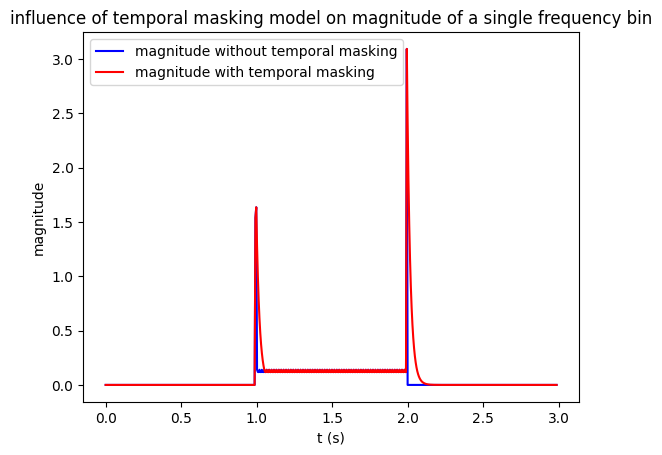

In [4]:
def IIRLowpassFilterFactor(SamplingFrequency, TimeOfMemoryInSeconds):
    assert TimeOfMemoryInSeconds > 0, 'memory time must be greater zero'
    assert SamplingFrequency > 0, 'sampling frequency must be greater zero'
    NormalizedGainAtEndOfMemory = 0.01
    NumberOfSamplesInMemory = TimeOfMemoryInSeconds * SamplingFrequency
    a = NormalizedGainAtEndOfMemory**(1/NumberOfSamplesInMemory)
    assert a < 1.0, 'low pass factor should be smaller than 1.0'
    assert a > 0.0, 'low pass factor should be greater than 0.0'
    return a

class CDenoiserTemporalMasking(object):

    def __init__(self, HopSizeInMilliSeconds, TimeConstantInSecondsForDampingconstant = 0.1):
        self.__buffer = 0.0
        SamplingRateForAnalysiswindows = 1000.0 / HopSizeInMilliSeconds
        self.__DampingConstant = IIRLowpassFilterFactor(SamplingRateForAnalysiswindows, TimeConstantInSecondsForDampingconstant)

    def TransferFunction(self, NewSpectra):
        output = np.zeros(NewSpectra.shape)
        for column in range(NewSpectra.shape[1]):
            output[:, column] = np.maximum(NewSpectra[:, column], self.__buffer)
            self.__buffer = output[:, column] * self.__DampingConstant
        return output
    
r = 48000
ws = 2**9
NyquistIndex = int(ws // 2 + 1)
hs = ws / 2
w = np.hanning(ws)
Delta_f = SamplingRate / ws
k = 10
f = Delta_f * k

x = np.zeros(3*r)
x[r:2*r] = np.sin(2*np.pi*f*np.arange(r)/r)
NumberOfBlocks = int((x.shape[0] - ws) // hs + 1)
X = np.zeros((NyquistIndex, NumberOfBlocks) )
for block in range(NumberOfBlocks):
    idx1 = int(block*hs)
    idx2 = int(idx1 + ws)
    X[:, block] = np.abs(np.fft.rfft(x[idx1:idx2] * w))
Denoiser = CDenoiserTemporalMasking(HopSizeInMilliSeconds = hs*1000/r, TimeConstantInSecondsForDampingconstant = 0.1)
Y = Denoiser.TransferFunction(X)

t = np.arange(X.shape[1]) * hs / r
plt.plot(t, X[k, :], 'b', label = 'magnitude without temporal masking') 
plt.plot(t, Y[k, :], 'r', label = 'magnitude with temporal masking')
plt.xlabel('t (s)')
plt.ylabel('magnitude')
plt.legend()
plt.title('influence of temporal masking model on magnitude of a single frequency bin')
plt.show()

## Frequency masking
In the following the procedures are used, which implements the psycho acoustic model of the book <cite>Schuller, Gerald: "Filter Banks and Audio Coding, Compressing Audio Signals Using Python"</cite>. For logarithmic frequency resolution, the [Bark-scale](../Basics/Bark.ipynb) is used.

In order to visualise the effects of frequency masking, a single block of audio is analysed by the FFT.

Spectra below the red plotted frequency masking threshold are not audible for human listeners and can be encoded with a large amount of noise.

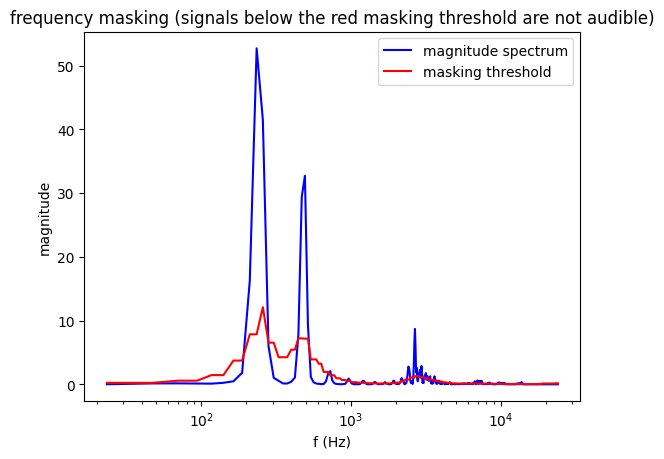

In [5]:
### source of import:
### https://github.com/TUIlmenauAMS/Python-Audio-Coder/blob/master/PythonPsychoacoustics/psyacmodel.py
import psyacmodel

x, r = WaveFileHandling.ReadWaveAsNumpyArray('../Audio/P501_D_EN_fm_SWB_48k.wav')
ws = 2**11
NyquistIndex = int(ws // 2 + 1)
hs = ws / 2
w = np.hanning(ws)
FFTLen = ws
maxfreq = r/2

block = 42
idx1 = int(block*hs)
idx2 = int(idx1 + ws)
mX = np.abs(np.fft.rfft(x[idx1:idx2] * w, n = FFTLen))

# configuration for evaluating masking thresholds
alpha = 0.8
nfilts = 64
spreadingfunctionBarkdB = psyacmodel.f_SP_dB(maxfreq, nfilts)
spreadingfuncmatrix = psyacmodel.spreadingfunctionmat(spreadingfunctionBarkdB, alpha, nfilts)
W = psyacmodel.mapping2barkmat(r, nfilts, FFTLen)
W_inv = psyacmodel.mappingfrombarkmat(W, FFTLen)

# evaluating masking thresholds
mXbark = psyacmodel.mapping2bark(mX, W , FFTLen)
mTbark = psyacmodel.maskingThresholdBark(mXbark, spreadingfuncmatrix, alpha, r, nfilts)
mT = psyacmodel.mappingfrombark(mTbark, W_inv, FFTLen)

f = np.arange(mX.shape[0]) * r / FFTLen
plt.semilogx(f[1:], mX[1:], 'b', label = 'magnitude spectrum')
plt.semilogx(f[1:], mT[1:], 'r', label = 'masking threshold')
plt.xlabel('f (Hz)')
plt.ylabel('magnitude')
plt.legend()
plt.title('frequency masking (signals below the red masking threshold are not audible)')
plt.show()

## Masking: Noise shaping
Frequency masking and temporal masking evaluates for each time-frequency bin of the spectrogram a Threshold of the maximum hearable level for humans.
The class noise shaping replaces the elements of the spectrogram, which lie below this Threshold by random levels between zero and the Threshold.

In [6]:
class CNoiseShaping(object):

    def __init__(self):
        self.__NumberOfBins = 1e-16
        self.__MaskedBins = 1e-16

    def Transform(self, OriginalColumn, MaskedColumn):
        PositionsWhereToAddNoise = MaskedColumn > OriginalColumn
        Output = np.copy(MaskedColumn)
        RandomColumn = np.random.rand(OriginalColumn.shape[0]) * MaskedColumn
        Output[PositionsWhereToAddNoise] = RandomColumn[PositionsWhereToAddNoise]
        self.__MaskedBins += np.sum(PositionsWhereToAddNoise)
        self.__NumberOfBins += OriginalColumn.shape[0]
        return Output

    def GetSparseness(self):
        return self.__MaskedBins / self.__NumberOfBins


## Masking: Putting everything together
In the following, a single class implements temporal masking, frequency masking and noise shaping.

In [7]:
class CMasking(object):

    def __init__(self, FFTLen, Fs, HopSizeInMilliseconds, TimeConstantInSecondsForDampingconstant, UseTemporalMasking = True):
        self.__nfilts = 64
        self.__alpha = 0.8
        self.__W = psyacmodel.mapping2barkmat(Fs, self.__nfilts, FFTLen)
        self.__W_inv = psyacmodel.mappingfrombarkmat(self.__W, FFTLen)
        maxfreq = Fs/2
        spreadingfunctionBarkdB = psyacmodel.f_SP_dB(maxfreq, self.__nfilts)
        self.__spreadingfuncmatrix = psyacmodel.spreadingfunctionmat(spreadingfunctionBarkdB, self.__alpha, self.__nfilts)
        self.__FFTLen = FFTLen
        self.__Fs = Fs
        self.__NoiseShaping = CNoiseShaping()
        self.__DenoiserTemporalMasking = CDenoiserTemporalMasking(HopSizeInMilliseconds, TimeConstantInSecondsForDampingconstant=TimeConstantInSecondsForDampingconstant)

    def Transform(self, mX):
        mXbark = psyacmodel.mapping2bark(mX, self.__W , self.__FFTLen)
        mTbark = psyacmodel.maskingThresholdBark(mXbark, self.__spreadingfuncmatrix, self.__alpha, self.__Fs, self.__nfilts)
        mT = psyacmodel.mappingfrombark(mTbark, self.__W_inv, self.__FFTLen)
        tmp = np.maximum(mX, mT)
        tmp = self.__DenoiserTemporalMasking.TransferFunction(tmp.reshape(-1,1)).flatten()
        SpectrumSynthesis = self.__NoiseShaping.Transform(mX, tmp)
        return SpectrumSynthesis

## Vocoder Configuration
The vocoder allows the manipulation of human speech with mathematical algorithms controlled by a set of parameters.
The aim of this Jupyter Notebook is to give you a tool, to learn about the influence or the effect of these parameters.

Simple toy parameter are TimeStretchFactor and PitchshiftFactor. These parameters are able to change the pitch and the speed of the human voice.

Additionally, the initial bandpass can be defined by the parameters CutoffFrequencyBandpassLowInHertz and CutoffFrequencyBandpassHighInHertz. Check, which values for these both parameters leads to a high voice intelligibility.

In [8]:
# defining the vocoder parameter
CutoffFrequencyBandpassLowInHertz = 50
CutoffFrequencyBandpassHighInHertz = 7000
TimeStretchFactor = 1.0
PitchshiftFactor = 1.0
TimeConstantInSecondsForDampingconstant = 0.1

HopSizeInMilliseconds = 10
OverlappingInPercent = 75
MinimumFrequencyResolutionInHertz = 20

# read the input signal
x, r = WaveFileHandling.ReadWaveAsNumpyArray('../Audio/P501_D_EN_fm_SWB_48k.wav')

print('sampling rate r = ', r, ' Hz')
print('duration of input signal = ', x.shape[0] / r, ' s')

# derived parameters and classes
hs = int(r * HopSizeInMilliseconds / 1000)
ws = int(hs / (1 - OverlappingInPercent/100))
w_Rectangular = np.ones((ws))
w_Hann = 0.5 - 0.5 * np.cos(2*np.pi*(np.arange(ws)+0.5)/ws)
FFTLen = int(r / MinimumFrequencyResolutionInHertz)
if FFTLen < ws: FFTLen = ws
FFTLen = 2*int(2**np.ceil(np.log2(FFTLen)))

Delta_f = r / FFTLen
CutoffIndexLowBandpass = int(CutoffFrequencyBandpassLowInHertz / Delta_f)
CutoffIndexHighBandpass = int(CutoffFrequencyBandpassHighInHertz / Delta_f) + 1

TargetHopSize = int(hs * TimeStretchFactor)

# initializing the necessary classes
ATransformPitchshift = CTransformPitchshift()
ARTISI = CRTISI(TargetHopSize, w_Rectangular, w_Hann)
AMasking = CMasking(FFTLen, r, HopSizeInMilliseconds, TimeConstantInSecondsForDampingconstant)

sampling rate r =  48000  Hz
duration of input signal =  6.0  s


## Vocoder Implementation
The input signal $x(n)$ is analysed blockwise:

A local spectrum SpectrumAnalysis is evaluated.
This SpectrumAnalysis is modified by different transformations/modifications, e.g. TransformPitchshift can be applied.
The output of these transformations is the SpectrumSynthesis.
The phase estimation algorithm estimates for this new magnitude spectrum SpectrumSynthesis a phase, which is matching the spectra processed earlier by the RTISI algorithm.
The output signal of the phase estimation algorithm is then added to $y(n)$ at the correct position in a overlap-add procedure in order to apply the timestretch.

In [9]:
y = np.zeros((int(x.shape[0] * TimeStretchFactor * 1.1)))
for NumberOfBlocks in range(int((x.shape[0] - ws) / hs)):
    # block analysis
    idx1 = NumberOfBlocks * hs
    idx2 = idx1 + ws
    BlockAnalysis = x[idx1:idx2] * w_Hann
    SpectrumAnalysis = np.fft.rfft(BlockAnalysis, n = FFTLen)
    angle = np.angle(SpectrumAnalysis)
    SpectrumAnalysis = np.abs(SpectrumAnalysis)

    # bandpass
    SpectrumAnalysis[:CutoffIndexLowBandpass] = 0.0
    SpectrumAnalysis[CutoffIndexHighBandpass:] = 0.0
    
    # pitch shift
    mX = ATransformPitchshift.TransformPitchshift(SpectrumAnalysis, SamplingRate = r, ShiftByFactor = PitchshiftFactor)
    # noise shaping by temporal masking and frequency masking
    SpectrumSynthesis = AMasking.Transform(mX)
    # estimate a reasonable phase for the next audio block
    BlockSynthesis = ARTISI.ProcessNewColumnOfSpectrogram(SpectrumSynthesis * np.exp(1j*angle))
    
    # overlap add at the target position due to timestretch
    idx1 = NumberOfBlocks * TargetHopSize
    idx2 = idx1 + ws
    y[idx1:idx2] += BlockSynthesis

# saving the results
#print('Sparseness: ', ASpectralMasking.GetSparsenessFactor())
print('duration of output signal = ', y.shape[0] / r, ' s')
WaveFileHandling.WriteWaveAsNumpyArray(y, r, 'output.wav')


duration of output signal =  6.6  s


## Programming exercise:
In the Jupyter Notebook you have learned, that humans analyse frequencies in a logarithmic way. This is typically modelled by the [Bark](../Basics/Bark.ipynb)-scale.

A better approximation of the Bark-scale is the following equation:

$b = 13\cdot\arctan\left(0.00076\cdot f\right)+3.5\cdot\arctan\left(\left(\frac{f}{7500}\right)^2\right)$

with $f$ in kHz.

The drawback of this equation is, that it cannot be inverted in closed form in order to evaluate frequency in kHz for a given Bark value.

Implement the two procedures Hertz2Bark and Bark2Hertz. For the procedure Bark2Hertz, a numerical solution must be implemented, e.g. bisection search.

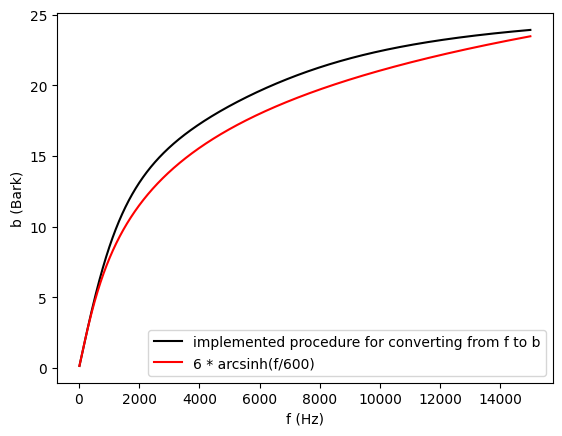

test_Bark2Hertz (__main__.TestProgrammingExercise.test_Bark2Hertz) ... ok
test_Hertz2Bark1 (__main__.TestProgrammingExercise.test_Hertz2Bark1) ... ok
test_Hertz2Bark2 (__main__.TestProgrammingExercise.test_Hertz2Bark2) ... ok
test_Hertz2Bark3 (__main__.TestProgrammingExercise.test_Hertz2Bark3) ... ok

----------------------------------------------------------------------
Ran 4 tests in 0.010s

OK


time consumption =  3.3532564640045166


In [10]:
import time

Precision = 1e-3

def Hertz2Bark(f):
    assert np.amin(f) >= 0, 'f should be greater or equal zero'
    b = 0.0
    ### solution begins
    b = 13 * np.arctan(0.00076 * f) + 3.5 * np.arctan((f / 7500)**2)
    ### solution ends
    return b

def Bark2Hertz(bark):    
    assert np.amin(bark) >= 0, 'b should be greater or equal zero'
    assert np.amax(bark) <= 24, 'b should be smaller or equal to 24'
    f = np.zeros(bark.shape)
    ### solution begins
    for i in range(bark.shape[0]):
        low = 0
        high = 24000
        while high - low > Precision:
            middle = (low + high) / 2
            if Hertz2Bark(middle) < bark[i]:
                low = middle
            else:
                high = middle
        f[i] = (low + high) / 2
    ### solution ends
    return f


f = np.arange(16, 15000)
b = Hertz2Bark(f)
plt.plot(f, b, 'k', label = 'implemented procedure for converting from f to b')
plt.plot(f, 6. * np.arcsinh(f/600.), 'r', label = '6 * arcsinh(f/600)')
plt.xlabel('f (Hz)')
plt.ylabel('b (Bark)')
plt.legend()
plt.show()
t0 = time.time()
f_approximation = Bark2Hertz(b)
t1 = time.time()
print('time consumption = ', t1-t0)

import unittest

class TestProgrammingExercise(unittest.TestCase):

    def test_Hertz2Bark1(self):
        f = 100
        self.assertAlmostEqual(Hertz2Bark(f), 0.986, delta = 1e-2)

    def test_Hertz2Bark2(self):
        f = 7000
        self.assertAlmostEqual(Hertz2Bark(f), 20.51, delta = 1e-2)

    def test_Hertz2Bark3(self):
        f = 1000
        self.assertAlmostEqual(Hertz2Bark(f), 8.51, delta = 1e-2)

    def test_Bark2Hertz(self):
        f = np.random.rand(1) * 15000 + 16
        b = Hertz2Bark(f)
        self.assertAlmostEqual(Bark2Hertz(b), f, delta = Precision)


    
unittest.main(argv=[''], verbosity=2, exit=False)

## Exam preparation:

1) The pitch shifting is done by linear interpolation of two neighbouring values. Assuming the result of the DFT at the given positions: $X\left(k=3\right)=7$ and $X\left(k=4\right)=17$. Evaluate the magnitudes at the positions $k=3.1$ and $k=3.6$ by linear interpolation (approximation of the envelope by a linear polynomial).

2) Additionally to part task 1) now also the value $X\left(k=5\right)=12$ is given. Evaluate the magnitudes at the positions $k=3.1$ and $k=3.6$ by quadratic interpolation (approximation of the envelope by a squared polynomial).

3) Is human voice understandable for different values of the parameter TimeStretchFactor?

4) Is human voice understandable for different values of the parameter PitchShiftFactor?

5) Explain in your own words the reason for using dataset augmentation.

6) Name examples for dataset augmentation in the context of image classification.

7) Name examples for dataset augmentation in the context of speech command classification.

8) Evaluate the corresponding Bark and mel value for the frequency $f=440$ Hz.

9) Evaluate the frequency resolution in Hertz of the human ear for $b=0$ Bark and $b=20$ Bark.

## Summary
After working with this Jupyter Notebook you should be able to explain the following topics:

- What is the aim of dataset augmentation?
- Give examples for audio dataset augmentation?
- Explain the Bark scale.